In [1]:
#import os

# Path to the IMDB dataset
#BASE_PATH = "./aclImdb"

#train_neg_path = os.path.join(BASE_PATH, "train", "neg")
#train_pos_path = os.path.join(BASE_PATH, "train", "pos")
import os
import urllib.request
import tarfile

DATASET_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATASET_FILE = "aclImdb_v1.tar.gz"
BASE_PATH = "./aclImdb"

# Download and extract the dataset only if it is not already available
if not os.path.exists(BASE_PATH):
    print("Downloading IMDB dataset...")
    urllib.request.urlretrieve(DATASET_URL, DATASET_FILE)

    print("Extracting dataset...")
    with tarfile.open(DATASET_FILE, "r:gz") as tar:
        tar.extractall(".")

    print("Dataset ready.")

train_neg_path = os.path.join(BASE_PATH, "train", "neg")
train_pos_path = os.path.join(BASE_PATH, "train", "pos")

Extracting dataset...


/tmp/ipykernel_1782/4273573000.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Dataset ready.


Sentiment Analysis of Movie Reviews Using NLP and Machine Learning
This project classifies IMDB movie review as positive or negative
Two approaches are compared
1. TF-IDF + Machine Learning
2. BERT - based Deep Learning

Models are evaluated using Accuracy , Precision , Recall , and F1-Score.

In [2]:
import os
import re
import time
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report


The Below code :
1- Reads movie review from folder
2-Labels them (positive/negative)
3- Combines them into a dataset
4- Converts into DataFrame
5- Shuffles the data

In [3]:
#Load IMDB dataset
def load_reviews_from_folder(folder_path, label,limit=None):
  reviews=[]
  files =os.listdir(folder_path)
  if limit:
    files=files[:limit]

  for filename in files:
    if filename.endswith(".txt"):
      with open(os.path.join(folder_path,filename),'r',encoding='utf-8',errors='ignore') as f:
        review=f.read()
        reviews.append({"review": review, "label": label})
  return reviews


#Base_Path="/content/drive/MyDrive/aclImdb" #Location of IMDB dataset in Google Drive
#Create training dataset
train_data = (
    load_reviews_from_folder(BASE_PATH + "/train/pos", 1, 12500) +
    load_reviews_from_folder(BASE_PATH + "/train/neg", 0, 12500)
)
#Create test dataset
test_data = (
    load_reviews_from_folder(BASE_PATH + "/test/pos", 1, 12500) +
    load_reviews_from_folder(BASE_PATH+ "/test/neg", 0, 12500)
)

#Convert to DataFrame
train_df = pd.DataFrame(train_data).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.DataFrame(test_data).sample(frac=1, random_state=42).reset_index(drop=True)

print(train_df.shape)
print(test_df.shape)
print(train_df.head())
print(train_df['review'].iloc[0][:300])



(25000, 2)
(25000, 2)
                                              review  label
0  This is a very difficult movie, and it's almos...      1
1  I rented this movie yesterday and can hardly e...      0
2  This story is a familiar one in the long-runni...      1
3  Ouch! This one was a bit painful to sit throug...      0
4  Wow, i'm a huge Henry VIII/Tudor era fan and, ...      0
This is a very difficult movie, and it's almost impossible to get a handle on what's going on. At first it seems to be a rather pedestrian movie about a guy (Trelkovsky) who needs an apartment and rather crassly invites himself into one when the current tenant (a woman) commits suicide. Then the twi


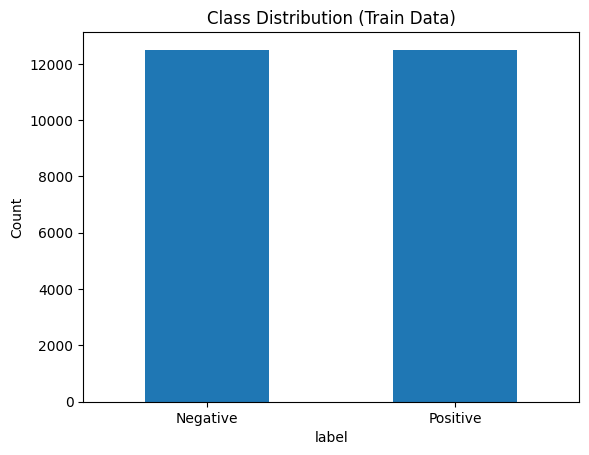

In [4]:
#DataSet Graph
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Train Data)")
plt.xticks([0,1], ['Negative','Positive'], rotation=0)
plt.ylabel("Count")
plt.show()

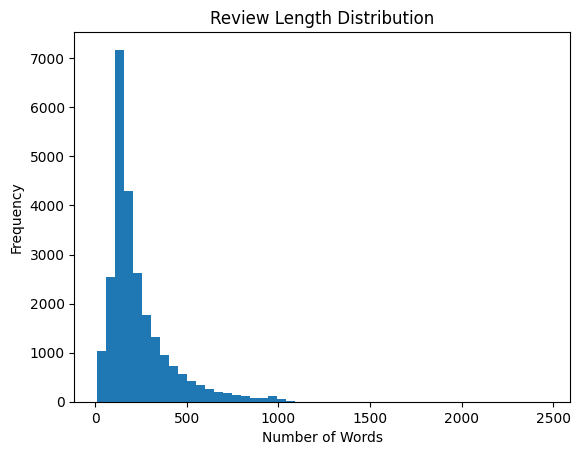

In [5]:
#Review Graph
train_df['review_length'] = train_df['review'].apply(lambda x: len(x.split()))

plt.hist(train_df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

##Text Preprocessing Step
It cleans raw movie reviews so models like TF-IDF, ML can understand them better

In [6]:
#pre -Processing
def clean_text(text):
    text = text.lower()

    # Contraction handling
    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # Remove HTML tags, punctuation, and extra spaces
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

train_df['clean_review'] = train_df['review'].apply(clean_text)
test_df['clean_review'] = test_df['review'].apply(clean_text)
print(train_df.columns)
print(test_df.columns)


Index(['review', 'label', 'review_length', 'clean_review'], dtype='object')
Index(['review', 'label', 'clean_review'], dtype='object')


##TF-IDF
TF-IDF is used to convert text data into numerical features by assigning weights to words based in their importance. Both unigrams and bigrams were used, while preserving important negation words such as "not","no", and "never"
Due to time constraints, only one stop word configuration was evaluated instead of comparing multiple stop word removal settings.

In [7]:
#TF-IDF
custom_stop_words=list(ENGLISH_STOP_WORDS - {'not','no','never'})
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words=custom_stop_words)
X_train = tfidf.fit_transform(train_df['clean_review'])
X_test = tfidf.transform(test_df['clean_review'])
y_train=train_df['label']
y_test=test_df['label']

##Model Training and Evaluation
In this step, three machine learning models - Logistic Regression , Support Vector Machine (SVM) , and Random Forest - were trained using TF-IDF feature representation . A function was implemeneted to automate the training and evaluation process for each model . The models was trained on the training dataset and evaluated on the test dataset to measure their generalization performance . Evaluation metrics such as Accuracy , Precision , Recall , and F1-score were used to compare the models . Additionally , training time and inference time were recorded to analyze computational efficiency.


 Model: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     12500
    Positive       0.88      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000


 Model: Linear SVM
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87     12500
    Positive       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000


 Model: Random Forest
              precision    recall  f1-score   support

    Negative       0.84      0.87      0.85     12500
    Positive       0.87      0.83      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
we

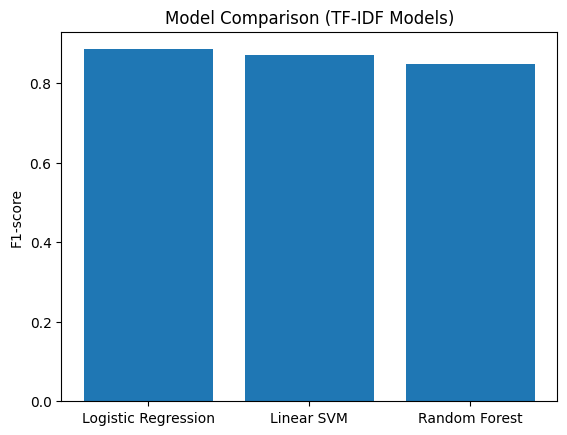

In [8]:
#Train and evaluate models
def evaluate_model(name,model):
  start=time.time()
  model.fit(X_train,y_train)
  train_time=time.time()-start
  start=time.time()
  y_pred=model.predict(X_test)
  inference_time=time.time()-start
  print("\n Model:", name)
  print(classification_report(y_test,y_pred,target_names=['Negative','Positive']))
  return{
      "Model":name,
      "Accuracy":accuracy_score(y_test,y_pred),
      "Precision":precision_score(y_test,y_pred),
      "Recall":recall_score(y_test,y_pred),
      "F1-score": f1_score(y_test,y_pred),
      "Training Time":train_time,
      "Inference Time":inference_time
  }

results=[]
results.append(evaluate_model("Logistic Regression",LogisticRegression(max_iter=1000)))
results.append(evaluate_model("Linear SVM",LinearSVC()))
results.append(evaluate_model("Random Forest",RandomForestClassifier(n_estimators=100,random_state=42)))

results_df = pd.DataFrame(results)

import matplotlib.pyplot as plt

plt.bar(results_df['Model'], results_df['F1-score'])
plt.title("Model Comparison (TF-IDF Models)")
plt.ylabel("F1-score")
plt.show()

## BERT Preprocessing

Unlike the TF-IDF pipeline, minimal preprocessing was applied for BERT. Stop words were not removed, and the original sentence structure was preserved because BERT relies on contextual embeddings and its own tokenizer to understand language. Only basic cleaning such as removing unnecessary spaces and characters was performed.

## BERT Fine-Tuning

For the transformer-based approach, I fine-tuned the pre-trained `bert-base-uncased` model for binary sentiment classification.

Unlike TF-IDF, BERT uses contextual representations, allowing it to understand words based on their surrounding context.

Due to computational constraints, I used a balanced subset of 4,000 training reviews (2,000 positive and 2,000 negative) and 500 test reviews (250 positive and 250 negative).

The model was fine-tuned using Hugging Face Transformers and PyTorch and evaluated using Accuracy, Precision, Recall, and F1-score.


In [9]:
!pip install transformers datasets evaluate accelerate -q

import torch
import numpy as np
from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.1 MB/s eta 0:00:00


In [10]:
#Train : 2000 pos + 2000 neg
pos_train=train_df[train_df['label']==1].sample(n=2000,random_state=42)
neg_train=train_df[train_df['label']==0].sample(n=2000,random_state=42)

bert_train_df=pd.concat([pos_train,neg_train]).sample(frac=1, random_state=42)

#Test : 250 pos + 250 neg
pos_test=test_df[test_df['label']==1].sample(n=250,random_state=42)
neg_test=test_df[test_df['label']==0].sample(n=250,random_state=42)

bert_test_df = pd.concat([pos_test, neg_test]).sample(frac=1, random_state=42)

#Keep only required columns
bert_train_df=bert_train_df[['review','label']]
bert_test_df=bert_test_df[['review','label']]

#Convert Pandas to Hugging Face Dataset
train_dataset=Dataset.from_pandas(bert_train_df.reset_index(drop=True))
test_dataset=Dataset.from_pandas(bert_test_df.reset_index(drop=True))

print(train_dataset)
print(test_dataset)


Dataset({
    features: ['review', 'label'],
    num_rows: 4000
})
Dataset({
    features: ['review', 'label'],
    num_rows: 500
})


In [11]:
#Load BERT Tokenizer
tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [12]:
#Tokenize text
def tokenize_function(examples):
  return tokenizer(examples['review'],padding='max_length',truncation=True,max_length=256)

train_dataset=train_dataset.map(tokenize_function,batched=True)
test_dataset=test_dataset.map(tokenize_function,batched=True)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [13]:
#Set Format for PyTorch
train_cols_to_remove=[col for col in ["review","__index_level_0__"]
                      if col in train_dataset.column_names]
test_cols_to_remove=[col for col in ["review","__index_level_0__"]
                      if col in test_dataset.column_names]
train_dataset= train_dataset.remove_columns(train_cols_to_remove)
test_dataset=test_dataset.remove_columns(test_cols_to_remove)
train_dataset.set_format("torch")
test_dataset.set_format("torch")
print(train_dataset.column_names)
print(test_dataset.column_names)



['label', 'input_ids', 'token_type_ids', 'attention_mask']
['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [14]:
#Load BERT classification model
model=BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=2)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
#Define Evaluation Metrics
def compute_metrics(eval_pred):
  logits,labels=eval_pred
  predictions=np.argmax(logits,axis=-1)
  return{
      'accuracy':accuracy_score(labels,predictions),
      'precision':precision_score(labels,predictions),
      'recall':recall_score(labels,predictions),
      'f1':f1_score(labels,predictions)
  }


In [16]:
# Fine-tune BERT for sentiment classification
training_args=TrainingArguments(
    output_dir='./bert_results',
    eval_strategy='epoch',
    save_strategy='no',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50
)

trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.332650,0.290901,0.894000,0.877395,0.916000,0.896282


TrainOutput(global_step=500, training_loss=0.3841416721343994, metrics={'train_runtime': 11623.7796, 'train_samples_per_second': 0.344, 'train_steps_per_second': 0.043, 'total_flos': 526222110720000.0, 'train_loss': 0.3841416721343994, 'epoch': 1.0})

In [17]:
# Evaluate the fine-tuned BERT model
bert_results= trainer.evaluate()
print(bert_results)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.332650,0.290901,1,0.894000,0.877395,0.916000,0.896282


{'eval_loss': 0.2909007668495178, 'eval_accuracy': 0.894, 'eval_precision': 0.8773946360153256, 'eval_recall': 0.916, 'eval_f1': 0.8962818003913894}


,Model,Accuracy,Precision,Recall,F1-score,Training Time,Inference Time
0,BERT,0.89400,0.877395,0.91600,0.896282,Higher,Higher
1,Logistic Regression,0.88508,0.884127,0.88632,0.885222,1.56497,0.012775
2,Linear SVM,0.87132,0.878682,0.86160,0.870057,0.736845,0.006944
3,Random Forest,0.85164,0.865956,0.83208,0.848680,70.263309,1.687532


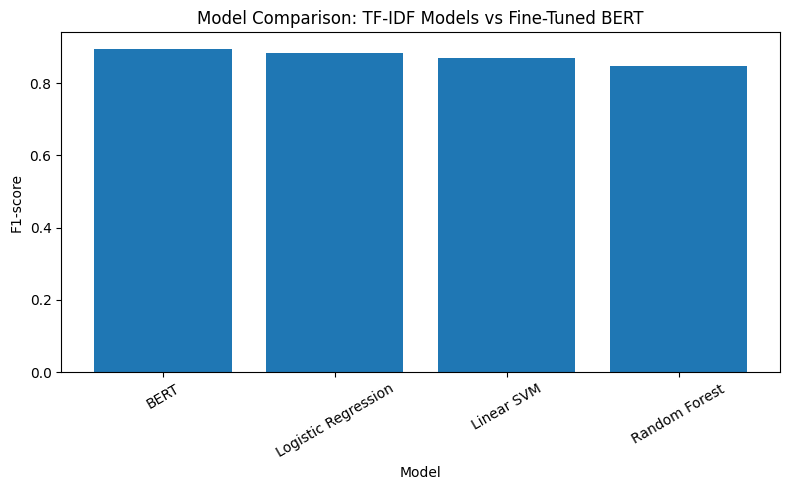

In [18]:
# Add BERT results to the model comparison table
bert_row= {
    "Model": "BERT",
    "Accuracy":bert_results['eval_accuracy'],
    "Precision":bert_results['eval_precision'],
    "Recall":bert_results['eval_recall'],
    "F1-score":bert_results['eval_f1'],
    "Training Time":"Higher",
    "Inference Time":"Higher"
}

# Combine traditional ML and BERT results
results_df = pd.DataFrame(results)

final_results_df = pd.concat(
    [results_df, pd.DataFrame([bert_row])],
    ignore_index=True
)

# Sort models by F1-score
final_results_df = final_results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

# Display final comparison
display(final_results_df)

# Visualize F1-score comparison
plt.figure(figsize=(8, 5))
plt.bar(final_results_df["Model"], final_results_df["F1-score"])
plt.title("Model Comparison: TF-IDF Models vs Fine-Tuned BERT")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()





## Conclusion

This project compared traditional machine learning approaches using TF-IDF with a fine-tuned BERT model for sentiment classification.

Among the models evaluated, BERT achieved the best overall performance with an accuracy of **89.40%** and an F1-score of **89.63%**. It also achieved the highest recall of **91.60%**.

Logistic Regression also performed well, achieving an accuracy of **88.51%** and an F1-score of **88.52%**, while requiring significantly fewer computational resources than BERT.

The results show the trade-off between traditional machine learning and transformer-based approaches. Fine-tuned BERT provided the best overall classification performance, while simpler TF-IDF-based models such as Logistic Regression remained competitive and computationally efficient.